In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

**Random Forest** is an ensemble learning method that combines multiple decision trees to improve performance and reduce overfitting.

> *"A forest of trees, each one slightly different, working together to make better predictions."*


| Concept | Description |
|---------|-------------|
| **Bootstrap Sampling** | Creates multiple datasets by sampling with replacement |
| **Feature Randomness** | Each tree uses a random subset of features |
| **Ensemble Learning** | Combines predictions from multiple models |
| **Bagging** | Bootstrap Aggregating — reduces variance |

| ✅ Advantages | ❌ Disadvantages |
|--------------|-----------------|
| Reduces overfitting | Less interpretable than single tree |
| Handles both classification and regression | Can be slow with large datasets |
| Handles missing data well | More memory intensive |
| Feature importance built-in | May overfit on noisy data |
| Works well with high-dimensional data | Black-box model |

Key Hyperparameters:

| Parameter | What It Does | Typical Values | Effect |
|-----------|--------------|----------------|--------|
| **`n_estimators`** | Number of trees | 100, 200, 500 | More trees = more stable (but slower) |
| **`max_depth`** | Maximum depth of each tree | 10, 20, None | Deeper = more complex (risk of overfitting) |
| **`min_samples_split`** | Min samples to split a node | 2, 5, 10 | Higher = simpler trees (less overfitting) |

**`min_samples_split`** is the **minimum number of samples required to split an internal node** in a decision tree.

> *"How many samples do I need at a node before I'm allowed to split it further?"*
> 
| Dataset Size | Recommended `min_samples_split` |
|--------------|--------------------------------|
| Small (< 1000) | 2-5 |
| Medium (1000-10000) | 5-10 |
| Large (> 10000) | 10-20 |
| Very Large (> 100k) | 20-50 |

```mermaid
graph TD
    A[Root Node<br>100 samples] -->|≥ 5? YES ✅| B[Node A<br>60 samples]
    A -->|≥ 5? YES ✅| C[Node B<br>40 samples]
    
    B -->|≥ 5? YES ✅| D[Leaf 1<br>3 samples]
    B -->|≥ 5? YES ✅| E[Leaf 2<br>57 samples]
    
    C -->|≥ 5? YES ✅| F[Leaf 3<br>38 samples]
    C -->|≥ 5? YES ✅| G[Leaf 4<br>2 samples]
    
    D -->|NO ❌ 3 < 5| H[STOP 🛑<br>Become a Leaf]
    E -->|YES ✅ 57 ≥ 5| I[CONTINUE 🌱<br>Split Further!]
    F -->|YES ✅ 38 ≥ 5| J[CONTINUE 🌱<br>Split Further!]
    G -->|NO ❌ 2 < 5| K[STOP 🛑<br>Become a Leaf]
    

| Parameter | What It Controls | Example |
|-----------|------------------|---------|
| **`min_samples_split`** | Minimum samples needed to **split** a node | "Can I split this node?" |
| **`min_samples_leaf`** | Minimum samples required in a **leaf** node | "How many samples must a leaf have?" |

If samples_in_node < min_samples_leaf:

STOP! 🛑
→ Become a LEAF node
→ Do NOT split further

In [27]:
# data
X, y = make_classification(
    n_samples=1000,        # 1000 samples
    n_features=4,          # 4 features
    n_informative=4,       # All features are useful
    n_redundant=0,         # No redundant features
    n_classes=2,           # Binary classification (0, 1)
    random_state=42
)

In [28]:
feature_names = ['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y
df

,Feature_1,Feature_2,Feature_3,Feature_4,Target
0,-2.439926,-1.371106,-0.025787,-0.102379,0
1,-0.366951,1.380114,0.583490,0.443968,1
2,-1.321133,-0.680427,0.749495,-0.281137,1
3,-0.330055,1.443556,0.508346,1.019528,1
4,-1.211829,-2.021848,0.143790,0.501954,0
...,...,...,...,...,...
995,-1.565182,-0.913232,0.495010,0.621762,1
996,-1.600971,2.692596,0.311441,2.504642,1
997,0.043325,-0.200804,-1.827989,-1.952151,0
998,0.259675,1.685565,-0.112371,1.995352,1


In [29]:
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify = maintain class distribution

In [32]:
# model
model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Maximum depth of each tree
    min_samples_split=5,   # Minimum samples to split a node
    min_samples_leaf=2,    # Minimum samples in a leaf
    random_state=42 
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [33]:
# predict
y_pred = model.predict(X_test)

### Precision, Recall, and F1-Score

The Confusion Matrix

- **TP** = True Positive (correctly predicted positive)
- **TN** = True Negative (correctly predicted negative)
- **FP** = False Positive (predicted positive, actually negative)
- **FN** = False Negative (predicted negative, actually positive)



**Precision**

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**What it measures:** Of all the instances you predicted as **positive**, how many were actually **positive**?

> *"When the model says 'Yes', how often is it right?"*



**Recall**

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**What it measures:** Of all the **actual positive** instances, how many did you correctly catch?

> *"How many of the actual 'Yes' cases did I catch?"*



**F1-Score**

$$
\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

**What it measures:** Harmonic mean of Precision and Recall.

**Why harmonic mean?** It punishes extreme values. You need BOTH precision and recall to be high.


| Metric | Class 0 | Class 1 | What It Means |
|--------|---------|---------|---------------|
| **Precision** | 0.89 | 0.95 | When predicting Class 1, you're 95% confident. Class 0: 89% confident. |
| **Recall** | 0.95 | 0.88 | You catch 95% of actual Class 0, but only 88% of actual Class 1. |
| **F1-Score** | 0.92 | 0.91 | Both classes have good balance. |

In [36]:
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
correct_predictions = np.trace(cm)
total_predictions = np.sum(cm)
accuracy = correct_predictions / total_predictions

print("\nConfusion Matrix:")
print(cm)


print(f"Correct predictions: {correct_predictions}")
print(f"Total predictions: {total_predictions}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

for i in range(cm.shape[0]):
    class_correct = cm[i, i]
    class_total = np.sum(cm[i, :])
    accuracy = class_correct / class_total
    print(f"Class {i} Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


MODEL EVALUATION
Accuracy: 0.9150

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.89      0.95      0.92       100
     Class 1       0.95      0.88      0.91       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200


Confusion Matrix:
[[95  5]
 [12 88]]
Correct predictions: 183
Total predictions: 200
Accuracy: 0.9150
Accuracy: 91.50%
Class 0 Accuracy: 0.9500 (95.00%)
Class 1 Accuracy: 0.8800 (88.00%)


In [38]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

importance = model.feature_importances_
for name, imp in zip(feature_names, importance):
    print(f"{name}: {imp:.4f}")

print(model.feature_importances_)


FEATURE IMPORTANCE
Feature_1: 0.1555
Feature_2: 0.2809
Feature_3: 0.3112
Feature_4: 0.2524
[0.1554989  0.28090384 0.3111882  0.25240906]


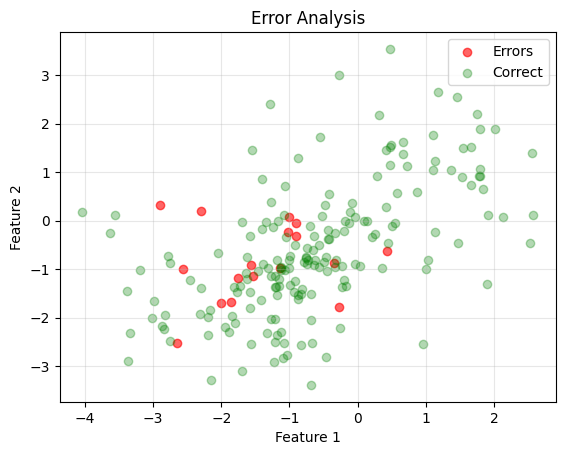

In [18]:
plt.figure()
errors = y_test != y_pred
error_indices = np.where(errors)[0]
plt.scatter(X_test[error_indices, 0], X_test[error_indices, 1], 
         color='red', alpha=0.6, label='Errors')
plt.scatter(X_test[~errors, 0], X_test[~errors, 1], 
         color='green', alpha=0.3, label='Correct')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Error Analysis')
plt.legend()
plt.grid(True, alpha=0.3)